In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

# Project root
PROJECT_ROOT = Path.cwd().parent

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.dataloader.loader import load_session

In [3]:
DATA_PATH = PROJECT_ROOT / "dataset" / "dhdata" / "sample_1.csv"

df, metadata = load_session(DATA_PATH)

print("Metadata:")
for key, value in metadata.items():
    print(f"{key}: {value}")

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Metadata:
file_name: sample_1.csv
file_path: /home/vutu0809/Desktop/NTSA_Foundation/phase1/dataset/dhdata/sample_1.csv
file_size_bytes: 4301683
n_rows: 117828
n_columns: 6

Shape:
(117828, 6)

Columns:
['Time (real)', 'IR Value raw', 'Unnamed: 2', 'Time (s)', 'Label', 'IR Value filtered']


,Time (real),IR Value raw,Unnamed: 2,Time (s),Label,IR Value filtered
0,4/4/2025 12:18,97422,NaN,2.63,0,-18
1,4/4/2025 12:18,97202,NaN,2.65,0,-223
2,4/4/2025 12:18,97118,NaN,2.67,0,-288
3,4/4/2025 12:18,97108,NaN,2.69,0,-279
4,4/4/2025 12:18,97106,NaN,2.71,0,-263


In [4]:
time = df["Time (s)"].to_numpy()
ppg_raw = df["IR Value raw"].to_numpy()
labels = df["Label"].to_numpy()

print(f"Time samples : {len(time)}")
print(f"PPG samples  : {len(ppg_raw)}")
print(f"Label samples: {len(labels)}")

print(f"\nTime range: {time[0]:.2f} -> {time[-1]:.2f} s")
print(f"PPG range : {ppg_raw.min()} -> {ppg_raw.max()}")
print(f"Labels    : {sorted(set(labels))}")

Time samples : 117828
PPG samples  : 117828
Label samples: 117828

Time range: 2.63 -> 2359.17 s
PPG range : 89195 -> 99781
Labels    : [np.int64(0), np.int64(1)]


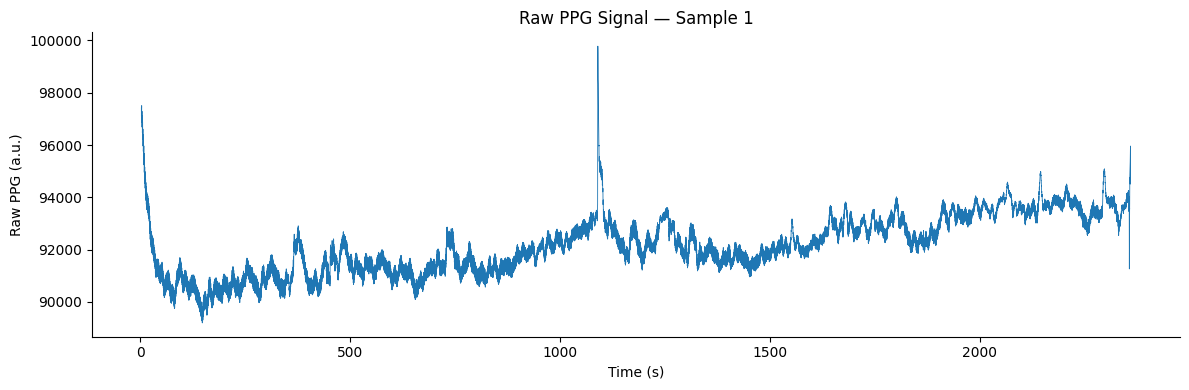

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(time, ppg_raw, linewidth=0.6)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Raw PPG (a.u.)")
ax.set_title("Raw PPG Signal — Sample 1")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

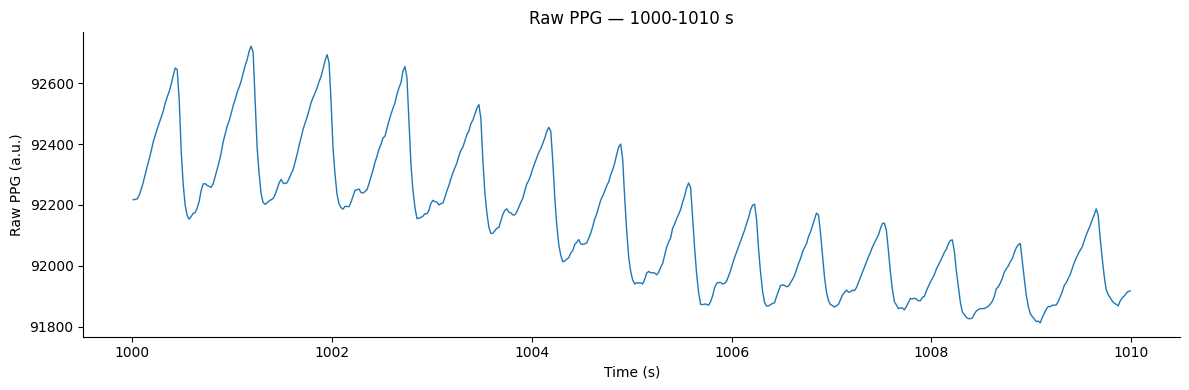

In [7]:
start_s = 1000
duration_s = 10

mask = (time >= start_s) & (time <= start_s + duration_s)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(time[mask], ppg_raw[mask], linewidth=1)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Raw PPG (a.u.)")
ax.set_title(f"Raw PPG — {start_s}-{start_s + duration_s} s")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [8]:
label_counts = pd.Series(labels).value_counts().sort_index()

awake_count = int(label_counts.get(0, 0))
drowsy_count = int(label_counts.get(1, 0))
total_count = len(labels)

awake_pct = awake_count / total_count * 100
drowsy_pct = drowsy_count / total_count * 100

print(f"Awake : {awake_count:,} samples ({awake_pct:.2f}%)")
print(f"Drowsy: {drowsy_count:,} samples ({drowsy_pct:.2f}%)")

Awake : 77,805 samples (66.03%)
Drowsy: 40,023 samples (33.97%)


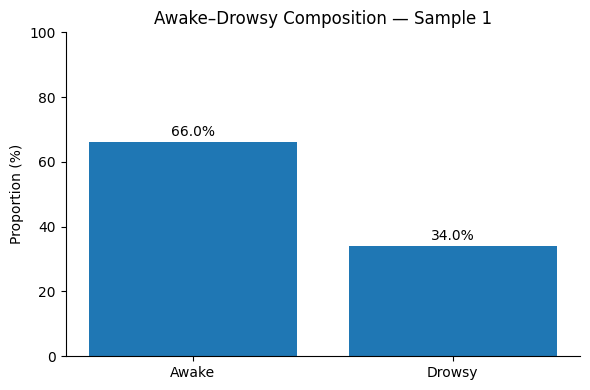

In [9]:
states = ["Awake", "Drowsy"]
percentages = [awake_pct, drowsy_pct]

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(states, percentages)

ax.set_ylabel("Proportion (%)")
ax.set_ylim(0, 100)
ax.set_title("Awake–Drowsy Composition — Sample 1")

for bar, value in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()